In [ ]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)

# TODO: Create the matrix described above
# Hint: Use np.ones and array slicing
import numpy as np

matrix = np.ones((5, 5))
matrix[1:4, 1:4] = 0
print(matrix)

# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)

# TODO: Normalize each column to have mean=0 and std=1
normalise = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print(normalise.mean(axis=0))
print(normalise.std(axis=0))

# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# TODO: Calculate theta_hat using the normal equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

# TODO: Print the estimated coefficients and compare with true_theta
print("Estimated:", theta_hat)
print("True: ", true_theta)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
[1. 1. 1.]
Estimated: [ 2.51723721 -1.19783796  3.72399266]
True:  [ 2.5 -1.2  3.7]


In [ ]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40),
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), "exam_score"] = np.nan
df.loc[np.random.choice(n_students, 5), "hours_studied"] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset
print(df.info())
print(df.describe())

# TODO: Identify and count missing values
print("Missing values:", df.isnull().sum())

# TODO: Fill missing exam_score with the mean score for the student's major
df["exam_score"] = df.groupby("major")["exam_score"].transform(
    lambda x: x.fillna(x.mean())
)

# TODO: Fill missing hours_studied with the median for the student's year
df["hours_studied"] = df.groupby("year")["hours_studied"].transform(
    lambda x: x.fillna(x.median())
)

# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major
print("Average score by major:", df.groupby("major")["exam_score"].mean())

# TODO: Find the major with the highest average exam_score
print("Best major:", df.groupby("major")["exam_score"].mean().idxmax())

# TODO: Calculate the correlation between hours_studied and exam_score
print("Correlation: ", df["hours_studied"].corr(df["exam_score"]))

# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
df["performance"] = pd.cut(
    df["exam_score"],
    bins=[0, 70, 80, 90, 100],
    labels=["Needs Improvement", "Average", "Good", "Excellent"],
)

# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
print(
    "By major and year:",
    df.groupby(["major", "year"]).agg(
        {"student_id": "count", "exam_score": "mean", "hours_studied": "mean"}
    ),
)

# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
print("Top 5 Students:", df.nlargest(5, "exam_score")[["student_id", "exam_score"]])

# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
print(
    "Pivot table:",
    df.pivot_table(values="exam_score", index="major", columns="year", aggfunc="mean"),
)

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   
50% 

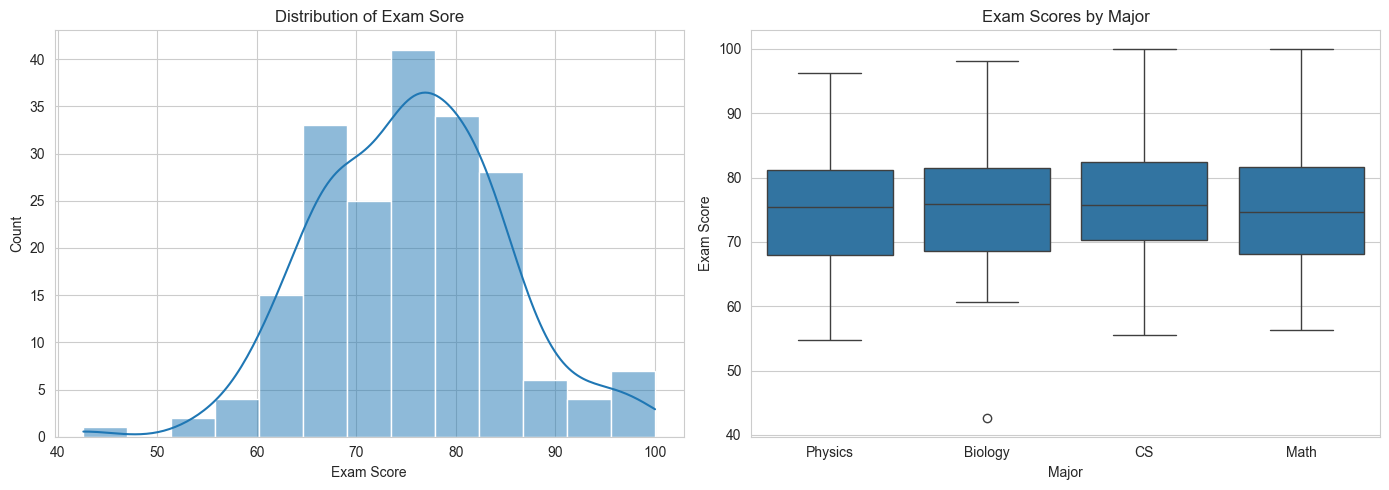

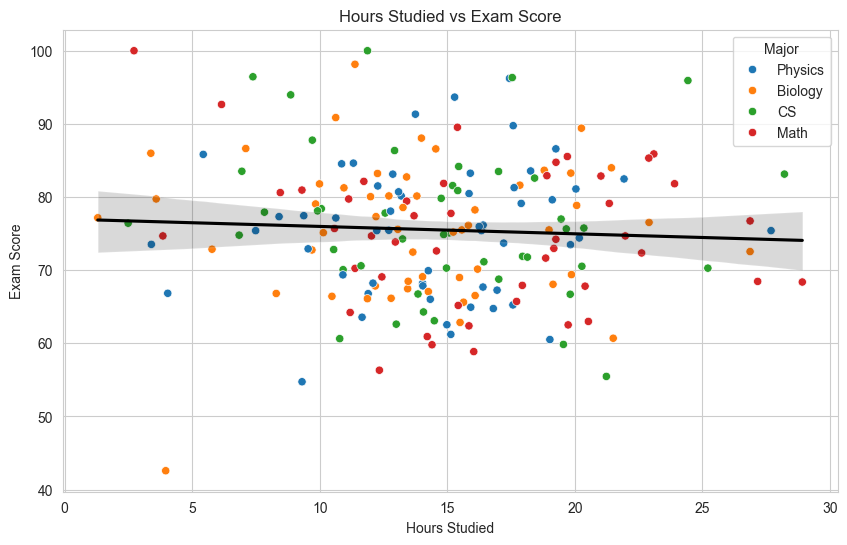

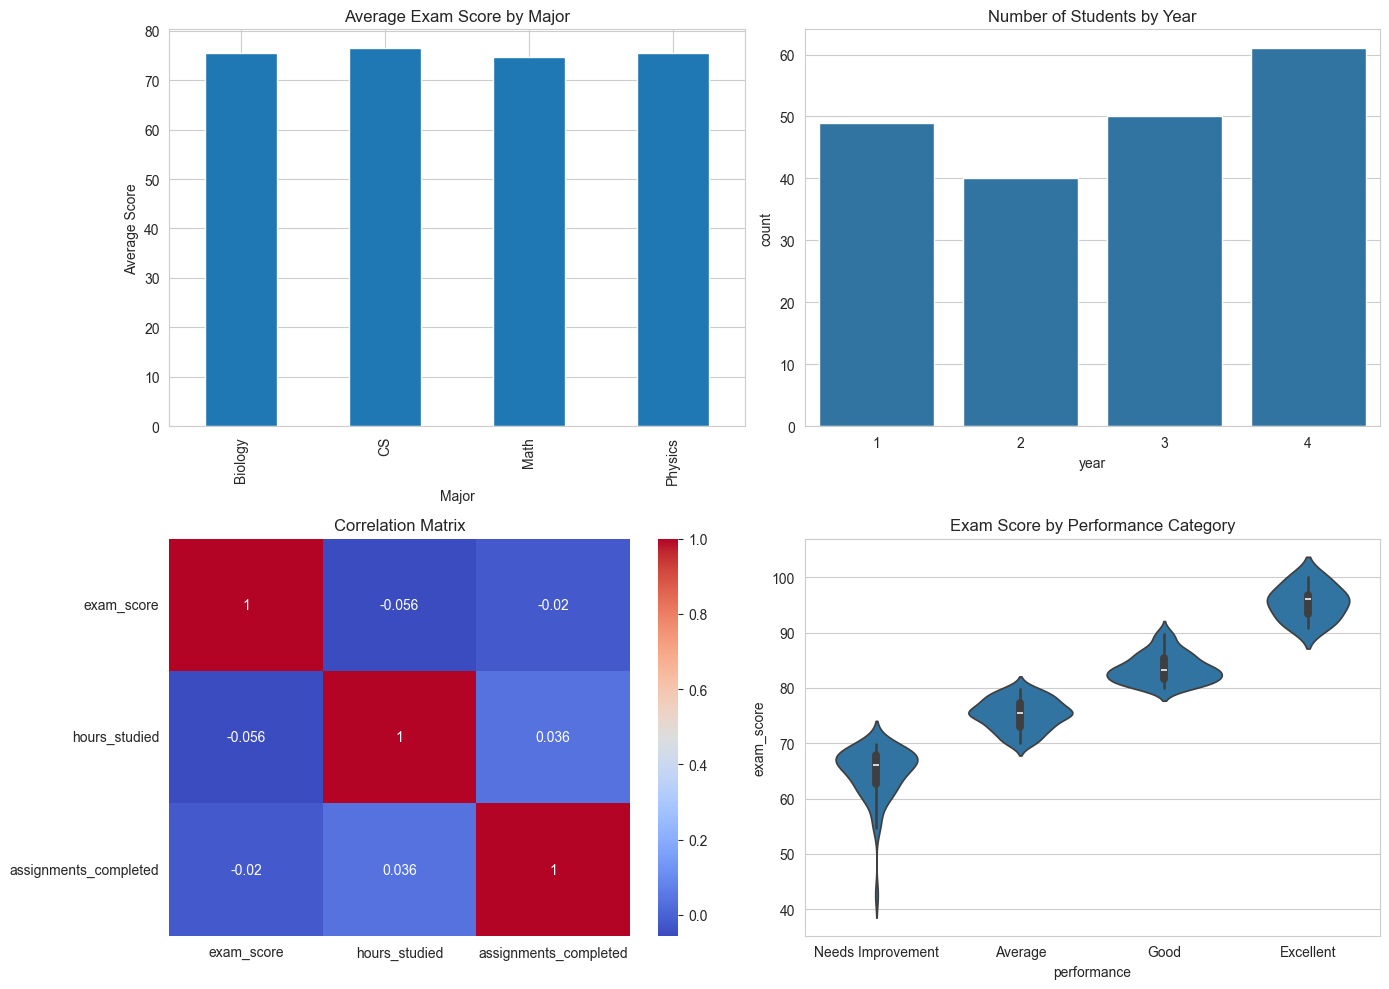

In [ ]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="exam_score", kde=True, ax=axes[0])
axes[0].set_title("Distribution of Exam Sore")
axes[0].set_xlabel("Exam Score")

sns.boxplot(data=df, x="major", y="exam_score", ax=axes[1])
axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

# TODO: Add appropriate titles, labels, and styling
plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="hours_studied", y="exam_score", hue="major")


# TODO: Add a regression line
sns.regplot(data=df, x="hours_studied", y="exam_score", scatter=False, color="black")

# TODO: Include appropriate legends, titles, and axis labels
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.show()

# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df.groupby("major")["exam_score"].mean().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_xlabel("Major")
axes[0, 0].set_ylabel("Average Score")

#       2. Count plot: Number of students by year
sns.countplot(data=df, x="year", ax=axes[0, 1])
axes[0, 1].set_title("Number of Students by Year")

#       3. Heat map: Correlation matrix of numerical columns
sns.heatmap(
    df[["exam_score", "hours_studied", "assignments_completed"]].corr(),
    annot=True,
    cmap="coolwarm",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Correlation Matrix")

#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability
sns.violinplot(data=df, x="performance", y="exam_score", ax=axes[1, 1])
axes[1, 1].set_title("Exam Score by Performance Category")

plt.tight_layout()
plt.show()

Age Group Summary:             num_customers    avg_income     avg_CLV      total_CLV
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683

Top 10% customers:  50


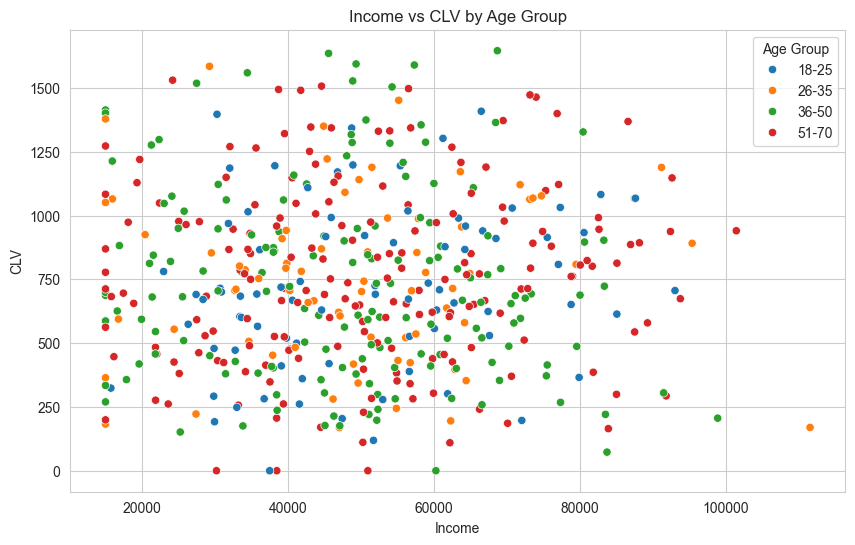

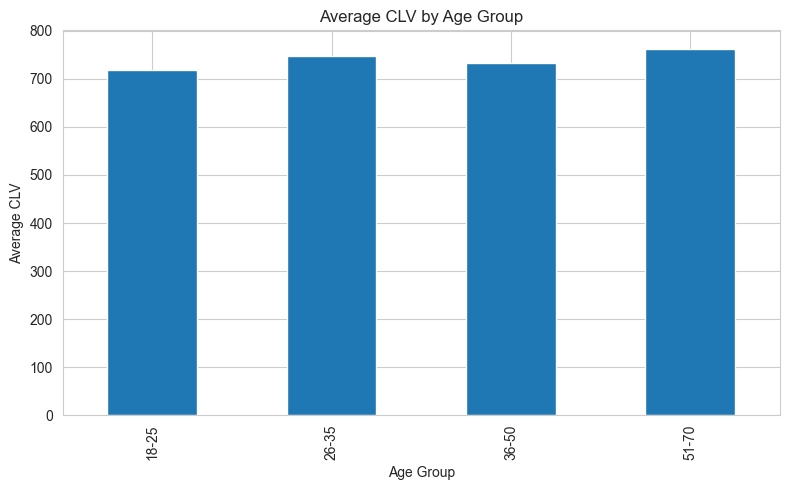

<function matplotlib.pyplot.show(close=None, block=None)>

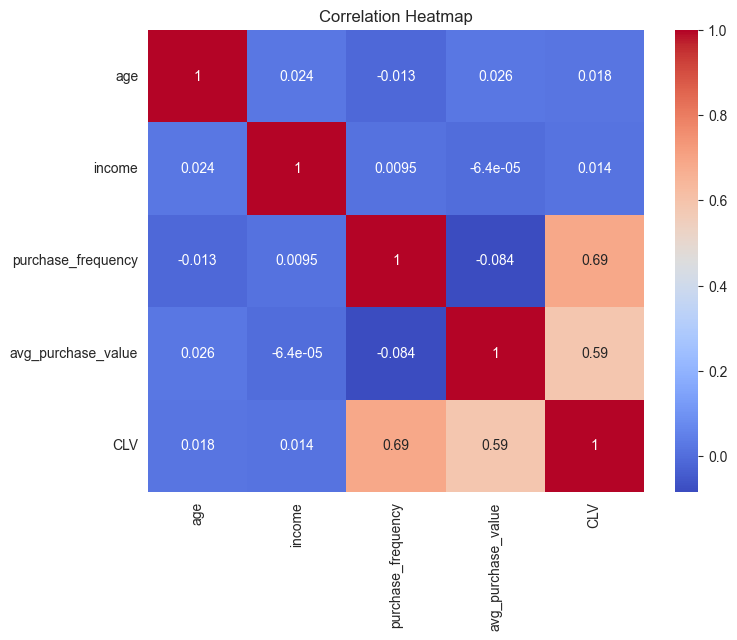

In [ ]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame(
    {
        "age": ages,
        "income": income,
        "purchase_frequency": purchase_freq,
        "avg_purchase_value": avg_purchase_value,
    }
)

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)
max_frequency = customers["purchase_frequency"].max()
customers["churn_risk"] = 1 - (customers["purchase_frequency"] / max_frequency)
customers["CLV"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 + customers["churn_risk"])
)

# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
customers["age_group"] = pd.cut(
    customers["age"],
    bins=[17, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"],
)

# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
age_group_summary = customers.groupby("age_group").agg(
    num_customers=("age", "count"),
    avg_income=("income", "mean"),
    avg_CLV=("CLV", "mean"),
    total_CLV=("CLV", "sum"),
)
print("Age Group Summary: ", age_group_summary)

# TODO: Identify top 10% of customers by CLV
top_10 = customers[customers["CLV"] >= customers["CLV"].quantile(0.90)]
print("\nTop 10% customers: ", len(top_10))

# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customers, x="income", y="CLV", hue="age_group")
plt.title("Income vs CLV by Age Group")
plt.xlabel("Income")
plt.ylabel("CLV")
plt.legend(title="Age Group")
plt.show()

#       2. Bar chart of average CLV by age group
plt.figure(figsize=(8, 5))
age_group_summary["avg_CLV"].plot(kind="bar")
plt.title("Average CLV by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average CLV")
plt.tight_layout()
plt.show()

#       3. Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    customers[
        ["age", "income", "purchase_frequency", "avg_purchase_value", "CLV"]
    ].corr(),
    annot=True,
    cmap="coolwarm",
)
plt.title("Correlation Heatmap")
plt.show


# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations
The 26-35 age group has the highest average CLV.
The purchase frequency is the strongest driver of CLV.
The income alone does not strongly predict CLV.
Top 10% of customers contribute disproportionately to total revenue.
